# IC3392: root causes and fixes for NebulaBayes and JY22/Peng2026

**Date:** 2026-08-24  
**Primary internal comparator:** O3N2-C20  
**Calibration translation check:** O3N2-M13 (the O3N2 calibration used in Peng et al. 2026)

This notebook follows the first-pass QC notebook and answers the narrower questions:

1. Why is the NebulaBayes map discrete, and what fixes the discreteness without hiding its pressure failure?
2. Is the JY22 distribution caused by the local implementation, or by poor applicability of the released model surface to IC3392?
3. Which changes are accepted in `SFR+Z.py`, and which residual problems must remain exposed as QC?

The downloaded FITS file is the **pre-fix test product**. Fixed-contract values below are read-only re-inferences/cached controlled runs from the same line measurements. This notebook asserts the input SHA-256 and never writes the science FITS or its log.

Important comparison convention: in IC3392, O3N2-C20 is about 0.21 dex above O3N2-M13. Therefore the Peng-paper M13 comparison is not interchangeable with the local C20 reference. JY22 is evaluated against both, but it is not tuned to either calibration.

In [1]:
from __future__ import annotations

import hashlib
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from scipy.stats import spearmanr

from model_grid_diagnostics import (
    JY22_FLAG_LOGU_EDGE,
    JY22_FLAG_OH_EDGE,
    JY22_FLAG_POOR_FIT,
    JY22_FORMAL_CHI2_MAX,
    NB_FLAG_LOGPK_EDGE,
    NB_FLAG_LOGU_EDGE,
    NB_FLAG_OH_EDGE,
    NB_FLAG_OPEN_CI68,
    load_jy22_grid,
)

ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
FITS_PATH = ROOT / "v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits"
GRID_PATH = ROOT / "Peng2026/photoionization_models/photoionization_grid_interpolated.fits"
PLAN_DIR = ROOT / ".planning/ic3392_diagnostic_root_cause_fixes_20260824"
VALIDATION_PATH = PLAN_DIR / "fixed_contract_validation.npz"
NB_CONTROL_PATH = PLAN_DIR / "nebulabayes_controlled_results.csv"

for path in (FITS_PATH, GRID_PATH, VALIDATION_PATH, NB_CONTROL_PATH):
    assert path.is_file(), f"Missing required input: {path}"

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def bin_values_to_map(bin_map, bin_ids, values, fill=np.nan):
    # Vectorised broadcast from one value per BIN_ID to a map.
    bin_map = np.asarray(bin_map)
    bin_ids = np.asarray(bin_ids, dtype=np.int64)
    values = np.asarray(values)
    order = np.argsort(bin_ids)
    sorted_ids = bin_ids[order]
    sorted_values = values[order]
    output = np.full(bin_map.shape, fill, dtype=np.result_type(values.dtype, float))
    finite = np.isfinite(bin_map)
    integer_ids = np.zeros(bin_map.shape, dtype=np.int64)
    integer_ids[finite] = bin_map[finite].astype(np.int64)
    positions = np.searchsorted(sorted_ids, integer_ids[finite])
    matched = positions < sorted_ids.size
    matched[matched] &= sorted_ids[positions[matched]] == integer_ids[finite][matched]
    flat_output = output[finite]
    flat_output[matched] = sorted_values[positions[matched]]
    output[finite] = flat_output
    return output

def values_for_bins(bin_map, image, bin_ids):
    # Take the first finite map value for each requested BIN_ID.
    bin_map = np.asarray(bin_map)
    image = np.asarray(image)
    keep = np.isfinite(bin_map) & np.isfinite(image)
    ids = bin_map[keep].astype(np.int64)
    vals = image[keep]
    order = np.argsort(ids, kind="stable")
    ids = ids[order]
    vals = vals[order]
    unique_ids, first = np.unique(ids, return_index=True)
    positions = np.searchsorted(unique_ids, np.asarray(bin_ids, dtype=np.int64))
    result = np.full(len(bin_ids), np.nan, dtype=float)
    matched = positions < unique_ids.size
    requested = np.asarray(bin_ids, dtype=np.int64)
    matched[matched] &= unique_ids[positions[matched]] == requested[matched]
    result[matched] = vals[first[positions[matched]]]
    return result

print(f"Science FITS (read only): {FITS_PATH}")
print(f"Fixed-contract validation: {VALIDATION_PATH}")

Science FITS (read only): /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits
Fixed-contract validation: /Users/Igniz/Desktop/ICRAR/further/.planning/ic3392_diagnostic_root_cause_fixes_20260824/fixed_contract_validation.npz


## 1. Freeze the input and reconstruct fixed-contract maps

All statistics are one value per fitted spatial bin, not one value per repeated map pixel. The validation archive was generated from the live raw/corrected six-line maps by the current diagnostic helpers. Its SHA guard prevents accidental comparison to a different FITS product.

In [2]:
required_hdus = (
    "BIN_ID",
    "O_H_O3N2_C20_HII",
    "O_H_O3N2_M13_HII",
    "O_H_PYQZ_HII",
    "O_H_NEBULABAYES_HII",
    "NB_VALID_HII",
    "O_H_JY22_HII",
    "JY22_VALID_HII",
    "SII6716_FLUX_CORR",
    "SII6730_FLUX_CORR",
)

with fits.open(FITS_PATH, memmap=False) as hdul:
    missing = sorted(set(required_hdus) - {hdu.name for hdu in hdul})
    assert not missing, f"Missing live HDUs: {missing}"
    maps = {
        name: np.asarray(hdul[name].data, dtype=np.float64).copy()
        for name in required_hdus
    }
    primary_header = hdul[0].header.copy()

with np.load(VALIDATION_PATH, allow_pickle=False) as archive:
    fixed = {name: np.asarray(archive[name]).copy() for name in archive.files}

live_sha = sha256(FITS_PATH)
expected_sha = str(fixed["input_sha256"])
assert live_sha == expected_sha, "The downloaded IC3392 FITS changed after validation."

bin_map = maps["BIN_ID"]
nb_ids = fixed["nb_full_bin_ids"].astype(np.int64)
jy_ids = fixed["jy_bin_ids"].astype(np.int64)

nb_mode = fixed["nb_full_standard_o_h"]
nb_mean = fixed["nb_full_standard_o_h_mean"]
nb_logu_mean = fixed["nb_full_standard_log_u_mean"]
nb_logpk_mean = fixed["nb_full_standard_log_pk_mean"]
nb_flag = fixed["nb_full_standard_flag"].astype(np.int64)
nb_oh_reliable = (
    np.isfinite(nb_mean)
    & np.isfinite(fixed["nb_full_standard_o_h_ci68_low"])
    & np.isfinite(fixed["nb_full_standard_o_h_ci68_high"])
    & ((nb_flag & NB_FLAG_OH_EDGE) == 0)
)
nb_logu_reliable = (
    np.isfinite(nb_logu_mean)
    & np.isfinite(fixed["nb_full_standard_log_u_ci68_low"])
    & np.isfinite(fixed["nb_full_standard_log_u_ci68_high"])
    & ((nb_flag & NB_FLAG_LOGU_EDGE) == 0)
)
nb_logpk_reliable = (
    np.isfinite(nb_logpk_mean)
    & np.isfinite(fixed["nb_full_standard_log_pk_ci68_low"])
    & np.isfinite(fixed["nb_full_standard_log_pk_ci68_high"])
    & ((nb_flag & NB_FLAG_LOGPK_EDGE) == 0)
)

fixed_maps = {
    "NB mean O/H": bin_values_to_map(bin_map, nb_ids, nb_mean),
    "NB sampled-mode O/H": bin_values_to_map(bin_map, nb_ids, nb_mode),
    "NB mean log U": bin_values_to_map(bin_map, nb_ids, nb_logu_mean),
    "NB mean log P/k": bin_values_to_map(bin_map, nb_ids, nb_logpk_mean),
    "NB logP reliable": bin_values_to_map(bin_map, nb_ids, nb_logpk_reliable.astype(float)),
    "JY post-depletion O/H": bin_values_to_map(bin_map, jy_ids, fixed["jy_o_h"]),
    "JY pre-depletion O/H": bin_values_to_map(bin_map, jy_ids, fixed["jy_o_h_pre"]),
    "JY log U": bin_values_to_map(bin_map, jy_ids, fixed["jy_log_u"]),
    "JY chi2": bin_values_to_map(bin_map, jy_ids, fixed["jy_chi2_min"]),
    "JY fit ok": bin_values_to_map(bin_map, jy_ids, fixed["jy_fit_ok"].astype(float)),
    "JY R3 residual": bin_values_to_map(bin_map, jy_ids, fixed["jy_resid_r3"]),
    "JY residual norm": bin_values_to_map(bin_map, jy_ids, fixed["jy_resid_norm"]),
}

finite_spatial = np.isfinite(maps["O_H_O3N2_C20_HII"])
ys, xs = np.where(finite_spatial)
y_slice = slice(int(ys.min()), int(ys.max()) + 1)
x_slice = slice(int(xs.min()), int(xs.max()) + 1)
map_extent = (xs.min() - 0.5, xs.max() + 0.5, ys.min() - 0.5, ys.max() + 0.5)

pyqz_at_jy = values_for_bins(bin_map, maps["O_H_PYQZ_HII"], jy_ids)
sii_ratio_map = np.divide(
    maps["SII6716_FLUX_CORR"],
    maps["SII6730_FLUX_CORR"],
    out=np.full(bin_map.shape, np.nan, dtype=float),
    where=np.isfinite(maps["SII6730_FLUX_CORR"]) & (maps["SII6730_FLUX_CORR"] != 0),
)
sii_ratio_nb = values_for_bins(bin_map, sii_ratio_map, nb_ids)

print(f"Input SHA-256: {live_sha}")
print(f"Map shape: {bin_map.shape}; NB bins: {nb_ids.size}; JY bins: {jy_ids.size}")
print("No FITS file was opened in update mode.")

Input SHA-256: 9705e283bb14ea895f0308da9693a78d6f0ee9ed04c678742fbef2ed6f78ce97
Map shape: (438, 437); NB bins: 2404; JY bins: 2404
No FITS file was opened in update mode.


## 2. Before/after scale and response summary

“Live” means the downloaded pre-fix product. “Fixed” means the accepted current contract applied to exactly the same IC3392 measurements. C20 is a QC comparator, not ground truth.

In [3]:
def comparison_row(label, values, c20):
    values = np.asarray(values, dtype=float)
    c20 = np.asarray(c20, dtype=float)
    keep = np.isfinite(values) & np.isfinite(c20)
    x = c20[keep]
    y = values[keep]
    return {
        "case": label,
        "n": int(keep.sum()),
        "p02": np.percentile(y, 2),
        "median": np.median(y),
        "p98": np.percentile(y, 98),
        "p98-p02": np.percentile(y, 98) - np.percentile(y, 2),
        "median minus C20": np.median(y - x),
        "rho(C20)": spearmanr(x, y).statistic if np.ptp(y) > 0 else np.nan,
        "OLS slope vs C20": np.polyfit(x, y, 1)[0] if np.ptp(y) > 0 else np.nan,
        "occupied values": np.unique(np.round(y, 8)).size,
    }

comparison = pd.DataFrame(
    [
        comparison_row("pyqz live", pyqz_at_jy, fixed["jy_c20"]),
        comparison_row("NebulaBayes live sampled mode", nb_mode, fixed["nb_full_c20"]),
        comparison_row("NebulaBayes fixed posterior mean", nb_mean, fixed["nb_full_c20"]),
        comparison_row("JY22 live pre-depletion + dusted ratios", fixed["jy_old_pre"], fixed["jy_c20"]),
        comparison_row("JY22 fixed raw-ratio pre-depletion", fixed["jy_o_h_pre"], fixed["jy_c20"]),
        comparison_row("JY22 fixed raw-ratio post-depletion", fixed["jy_o_h"], fixed["jy_c20"]),
    ]
).set_index("case")

common_reference = np.isfinite(fixed["jy_c20"]) & np.isfinite(fixed["jy_m13"])
c20_minus_m13 = np.median(fixed["jy_c20"][common_reference] - fixed["jy_m13"][common_reference])
display(comparison.round(4))
print(f"IC3392 median C20 - M13 = {c20_minus_m13:+.4f} dex")

IC3392 median C20 - M13 = +0.2118 dex


,n,p02,median,p98,p98-p02,median minus C20,rho(C20),OLS slope vs C20,occupied values
case,,,,,,,,,
pyqz live,2394,8.6390,8.7391,8.8294,0.1904,-0.0419,0.5325,0.8065,2394
NebulaBayes live sampled mode,2403,8.6692,8.8949,9.0078,0.3386,0.1063,0.6787,1.8183,31
NebulaBayes fixed posterior mean,2403,8.6379,8.8796,9.0156,0.3778,0.1010,0.6920,2.0828,2403
JY22 live pre-depletion + dusted ratios,2403,8.9591,9.0869,9.1800,0.2209,0.3044,0.0903,0.0687,1990
JY22 fixed raw-ratio pre-depletion,2403,8.9591,9.0545,9.1560,0.1969,0.2953,0.1214,0.1044,2004
JY22 fixed raw-ratio post-depletion,2403,8.7391,8.8345,8.9360,0.1969,0.0753,0.1214,0.1044,2004


## 3. NebulaBayes: the discrete estimator and the separate pressure failure

NebulaBayes 0.9.9 reports `axis[argmax(PDF_1D)]`: a sampled one-dimensional marginal mode. Even after interpolation to 160 O/H nodes, that reported value must remain on a node. A denser grid makes smaller steps but does not change this estimator property.

The accepted fix is a quadrature-normalised marginal posterior **mean** for the public central O/H, log U, and log(P/k), while retaining the package sampled modes in explicit companion products. Pressure boundary failures remain visible through parameter-specific reliability maps.

In [4]:
nb_control = pd.read_csv(NB_CONTROL_PATH)
standard_160 = nb_control.loc[nb_control["variant"] == "standard_160"]
standard_320 = nb_control.loc[nb_control["variant"] == "standard_320"]
density_pair = standard_160.merge(
    standard_320, on="bin_id", suffixes=("_160", "_320"), validate="one_to_one"
)

nb_keep = np.isfinite(nb_mode) & np.isfinite(nb_mean)
nb_metrics = pd.Series(
    {
        "full bins with finite mode and mean": int(nb_keep.sum()),
        "occupied sampled-mode O/H values": np.unique(np.round(nb_mode[nb_keep], 8)).size,
        "occupied posterior-mean O/H values": np.unique(np.round(nb_mean[nb_keep], 8)).size,
        "max |mean(320)-mean(160)| (dex)": np.max(
            np.abs(density_pair["o_h_mean_320"] - density_pair["o_h_mean_160"])
        ),
        "max |median(320)-median(160)| (dex)": np.max(
            np.abs(density_pair["o_h_median_320"] - density_pair["o_h_median_160"])
        ),
        "O/H reliable fraction": np.mean(nb_oh_reliable),
        "log U reliable fraction": np.mean(nb_logu_reliable),
        "log P/k reliable fraction": np.mean(nb_logpk_reliable),
        "log P/k edge fraction": np.mean((nb_flag & NB_FLAG_LOGPK_EDGE) != 0),
        "open/non-finite CI flag fraction": np.mean((nb_flag & NB_FLAG_OPEN_CI68) != 0),
    },
    name="value",
)
display(nb_metrics.to_frame())

,value
full bins with finite mode and mean,2404.000000
occupied sampled-mode O/H values,32.000000
occupied posterior-mean O/H values,2404.000000
max |mean(320)-mean(160)| (dex),0.000090
max |median(320)-median(160)| (dex),0.000610
O/H reliable fraction,1.000000
log U reliable fraction,1.000000
log P/k reliable fraction,0.444676
log P/k edge fraction,0.555324
open/non-finite CI flag fraction,0.370632


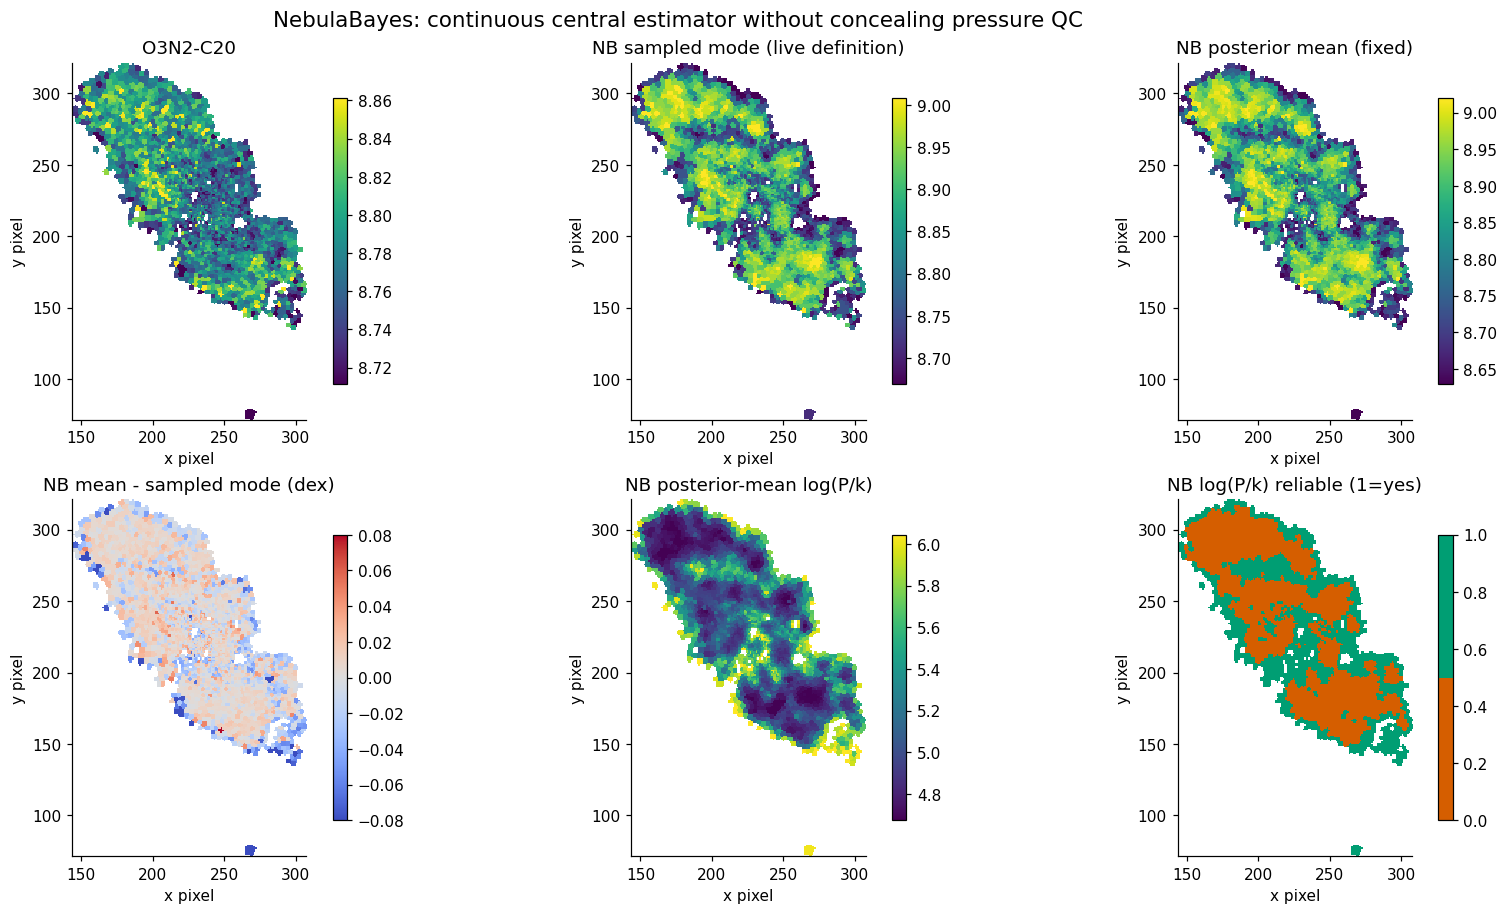

In [5]:
def robust_map(ax, data, title, cmap="viridis", percentile=(2, 98), norm=None, vmin=None, vmax=None):
    cropped = np.asarray(data[y_slice, x_slice], dtype=float)
    finite = cropped[np.isfinite(cropped)]
    if norm is None and (vmin is None or vmax is None):
        vmin, vmax = np.percentile(finite, percentile)
        if np.isclose(vmin, vmax):
            vmin, vmax = finite.min(), finite.max()
    image = ax.imshow(
        cropped,
        origin="lower",
        extent=map_extent,
        cmap=cmap,
        interpolation="nearest",
        norm=norm,
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
    plt.colorbar(image, ax=ax, shrink=0.80)

delta_nb = fixed_maps["NB mean O/H"] - fixed_maps["NB sampled-mode O/H"]
delta_limit = np.nanpercentile(np.abs(delta_nb), 98)

fig, axes = plt.subplots(2, 3, figsize=(15, 8.2), constrained_layout=True)
robust_map(axes[0, 0], maps["O_H_O3N2_C20_HII"], "O3N2-C20")
robust_map(axes[0, 1], fixed_maps["NB sampled-mode O/H"], "NB sampled mode (live definition)")
robust_map(axes[0, 2], fixed_maps["NB mean O/H"], "NB posterior mean (fixed)")
robust_map(
    axes[1, 0], delta_nb, "NB mean - sampled mode (dex)", cmap="coolwarm",
    norm=TwoSlopeNorm(vcenter=0.0, vmin=-delta_limit, vmax=delta_limit),
)
robust_map(axes[1, 1], fixed_maps["NB mean log P/k"], "NB posterior-mean log(P/k)")
robust_map(
    axes[1, 2], fixed_maps["NB logP reliable"], "NB log(P/k) reliable (1=yes)",
    cmap=ListedColormap(["#D55E00", "#009E73"]), vmin=0, vmax=1,
)
fig.suptitle("NebulaBayes: continuous central estimator without concealing pressure QC", fontsize=14)
plt.show()

Observed [S II] ratio p16, p50, p84: [1.34884895 1.46891979 1.61951936]
Lowest-pressure native-grid comparison band: 1.433 to 1.465


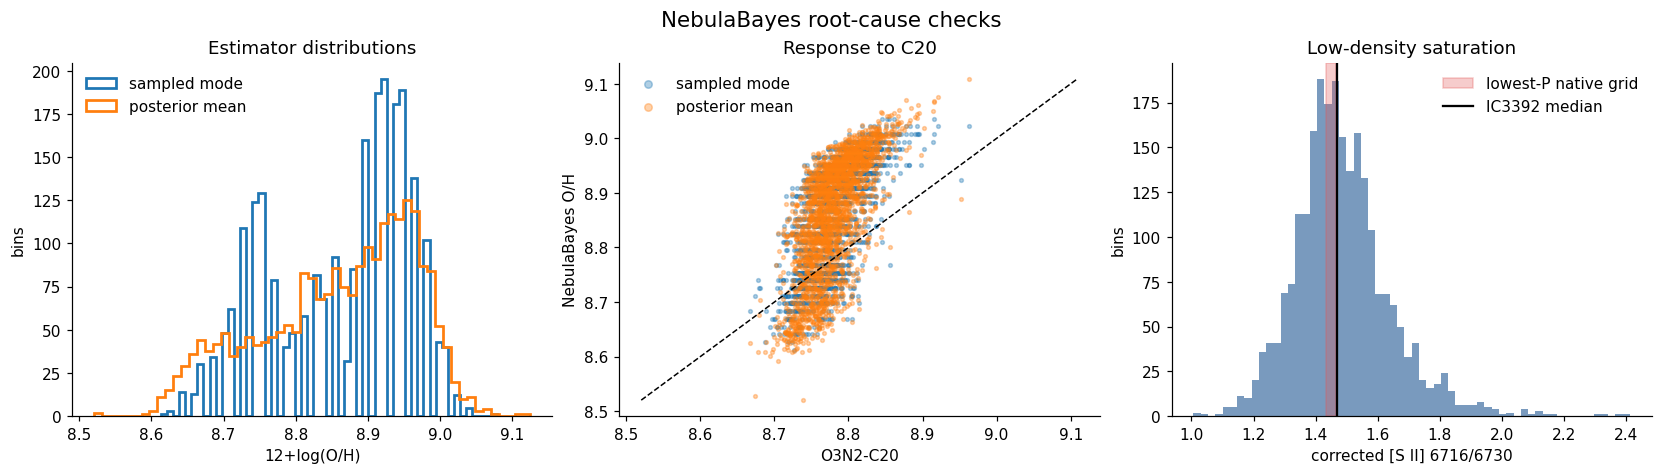

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

axes[0].hist(nb_mode[np.isfinite(nb_mode)], bins=55, histtype="step", lw=1.8, label="sampled mode")
axes[0].hist(nb_mean[np.isfinite(nb_mean)], bins=55, histtype="step", lw=1.8, label="posterior mean")
axes[0].set(xlabel="12+log(O/H)", ylabel="bins", title="Estimator distributions")
axes[0].legend(frameon=False)

common_nb = np.isfinite(fixed["nb_full_c20"]) & np.isfinite(nb_mean) & np.isfinite(nb_mode)
axes[1].scatter(fixed["nb_full_c20"][common_nb], nb_mode[common_nb], s=6, alpha=0.35, label="sampled mode")
axes[1].scatter(fixed["nb_full_c20"][common_nb], nb_mean[common_nb], s=6, alpha=0.35, label="posterior mean")
limits = [
    min(fixed["nb_full_c20"][common_nb].min(), nb_mean[common_nb].min()),
    max(fixed["nb_full_c20"][common_nb].max(), nb_mean[common_nb].max()),
]
axes[1].plot(limits, limits, "k--", lw=1)
axes[1].set(xlabel="O3N2-C20", ylabel="NebulaBayes O/H", title="Response to C20")
axes[1].legend(frameon=False, markerscale=2)

finite_sii = sii_ratio_nb[np.isfinite(sii_ratio_nb)]
axes[2].hist(finite_sii, bins=60, color="#4C78A8", alpha=0.75)
axes[2].axvspan(1.433, 1.465, color="#E45756", alpha=0.30, label="lowest-P native grid")
axes[2].axvline(np.median(finite_sii), color="black", lw=1.5, label="IC3392 median")
axes[2].set(xlabel="corrected [S II] 6716/6730", ylabel="bins", title="Low-density saturation")
axes[2].legend(frameon=False)

fig.suptitle("NebulaBayes root-cause checks", fontsize=14)
plt.show()

print("Observed [S II] ratio p16, p50, p84:", np.percentile(finite_sii, [16, 50, 84]))
print("Lowest-pressure native-grid comparison band: 1.433 to 1.465")

### NebulaBayes decision

- **Fixed:** numerical banding in the public central maps. The posterior mean is continuous and changes by less than $10^{-4}$ dex when only O/H sampling is doubled from 160 to 320 nodes in the controlled sample.
- **Preserved for audit:** the package-native sampled marginal mode and all existing CI/flag products.
- **Not “smoothed away”:** many [S II] ratios are at or beyond the lowest-pressure model behavior. `NB_LOGPK_RELIABLE` is therefore essential; a finite log(P/k) is not automatically science-ready.
- **Additional semantic issue:** `NB_CHI2_RED` is the package diagnostic at the tuple of separate marginal modes and excludes the 10% grid error used by the posterior. It is retained, but it is not a conventional goodness-of-fit statistic for the new posterior means.

Increasing the interpolation density or replacing the two [S II] lines by their sum was rejected as a silent fix. The summed-line experiment materially changes O/H while still leaving pressure boundary dominated.

## 4. JY22/Peng2026: two implementation defects, then a real model-locus failure

Two local contract errors explain most of the apparent abundance zero-point problem:

1. The released JY22 abundance axis is **pre-depletion**, whereas C20/M13 are gas-phase comparators. Ji & Yan specify $\mathrm{O/H}_{pre}=\mathrm{O/H}_{post}+0.22$ dex.
2. N2, S2, and R3 are close-pair ratios used raw in this method. The old script unnecessarily Balmer-corrected them and propagated dust-correction covariance.

The fixed public `O_H_JY22` is post-depletion; explicit `O_H_JY22_PREDEP` products retain the native model scale. The following tests ask what remains after both fixes.

In [7]:
jy_valid = fixed["jy_valid"] == 1
jy_common = jy_valid & np.isfinite(fixed["jy_c20"]) & np.isfinite(fixed["jy_m13"])
jy_flags = fixed["jy_flag"].astype(np.int64)

jy_metrics = pd.Series(
    {
        "numerically valid bins": int(jy_valid.sum()),
        "live old pre-depletion median": np.nanmedian(fixed["jy_old_pre"]),
        "fixed raw-ratio pre-depletion median": np.nanmedian(fixed["jy_o_h_pre"]),
        "fixed post-depletion median": np.nanmedian(fixed["jy_o_h"]),
        "fixed post minus C20 median (dex)": np.median(fixed["jy_o_h"][jy_common] - fixed["jy_c20"][jy_common]),
        "fixed post minus M13 median (dex)": np.median(fixed["jy_o_h"][jy_common] - fixed["jy_m13"][jy_common]),
        "rho(fixed post, C20)": spearmanr(fixed["jy_c20"][jy_common], fixed["jy_o_h"][jy_common]).statistic,
        "OLS response slope vs C20": np.polyfit(fixed["jy_c20"][jy_common], fixed["jy_o_h"][jy_common], 1)[0],
        "median minimum chi2": np.median(fixed["jy_chi2_min"][jy_valid]),
        f"fit-ok fraction (chi2 <= {JY22_FORMAL_CHI2_MAX:g})": np.mean(fixed["jy_fit_ok"][jy_valid] == 1),
        "O/H edge fraction": np.mean((jy_flags[jy_valid] & JY22_FLAG_OH_EDGE) != 0),
        "log U edge fraction": np.mean((jy_flags[jy_valid] & JY22_FLAG_LOGU_EDGE) != 0),
        "poor-fit flag fraction": np.mean((jy_flags[jy_valid] & JY22_FLAG_POOR_FIT) != 0),
        "median R3 residual (obs-model, dex)": np.median(fixed["jy_resid_r3"][jy_valid]),
        "median 3-ratio residual norm (dex)": np.median(fixed["jy_resid_norm"][jy_valid]),
    },
    name="value",
)
display(jy_metrics.to_frame())

# Frozen from the controlled run in PLAN_DIR/test_jy22_causes.py;
# the exact experiment and interpretation are recorded in findings.md.
subset_summary = pd.DataFrame(
    {
        "ratio subset": ["N2 + S2", "N2 + R3", "S2 + R3"],
        "median pre-depletion O/H": [9.062, 8.783, 8.402],
        "interpretation": [
            "N2/S2-dominated high-O/H solution",
            "intermediate solution",
            "R3/S2 favor much lower O/H",
        ],
    }
).set_index("ratio subset")
pairwise_disagreement = pd.Series(
    {"N2+S2 minus N2+R3": 0.277, "N2+S2 minus S2+R3": 0.725, "N2+R3 minus S2+R3": 0.533},
    name="median O/H disagreement (dex)",
)
display(Markdown("**Controlled raw-ratio subset inference (same IC3392 bins and released grid)**"))
display(subset_summary)
display(pairwise_disagreement.to_frame())

,value
numerically valid bins,2404.000000
live old pre-depletion median,9.087004
fixed raw-ratio pre-depletion median,9.054564
fixed post-depletion median,8.834564
fixed post minus C20 median (dex),0.075325
fixed post minus M13 median (dex),0.287081
"rho(fixed post, C20)",0.120245
OLS response slope vs C20,0.100317
median minimum chi2,53.313334
fit-ok fraction (chi2 <= 9),0.183028


**Controlled raw-ratio subset inference (same IC3392 bins and released grid)**

,median pre-depletion O/H,interpretation
ratio subset,,
N2 + S2,9.062,N2/S2-dominated high-O/H solution
N2 + R3,8.783,intermediate solution
S2 + R3,8.402,R3/S2 favor much lower O/H


,median O/H disagreement (dex)
N2+S2 minus N2+R3,0.277
N2+S2 minus S2+R3,0.725
N2+R3 minus S2+R3,0.533


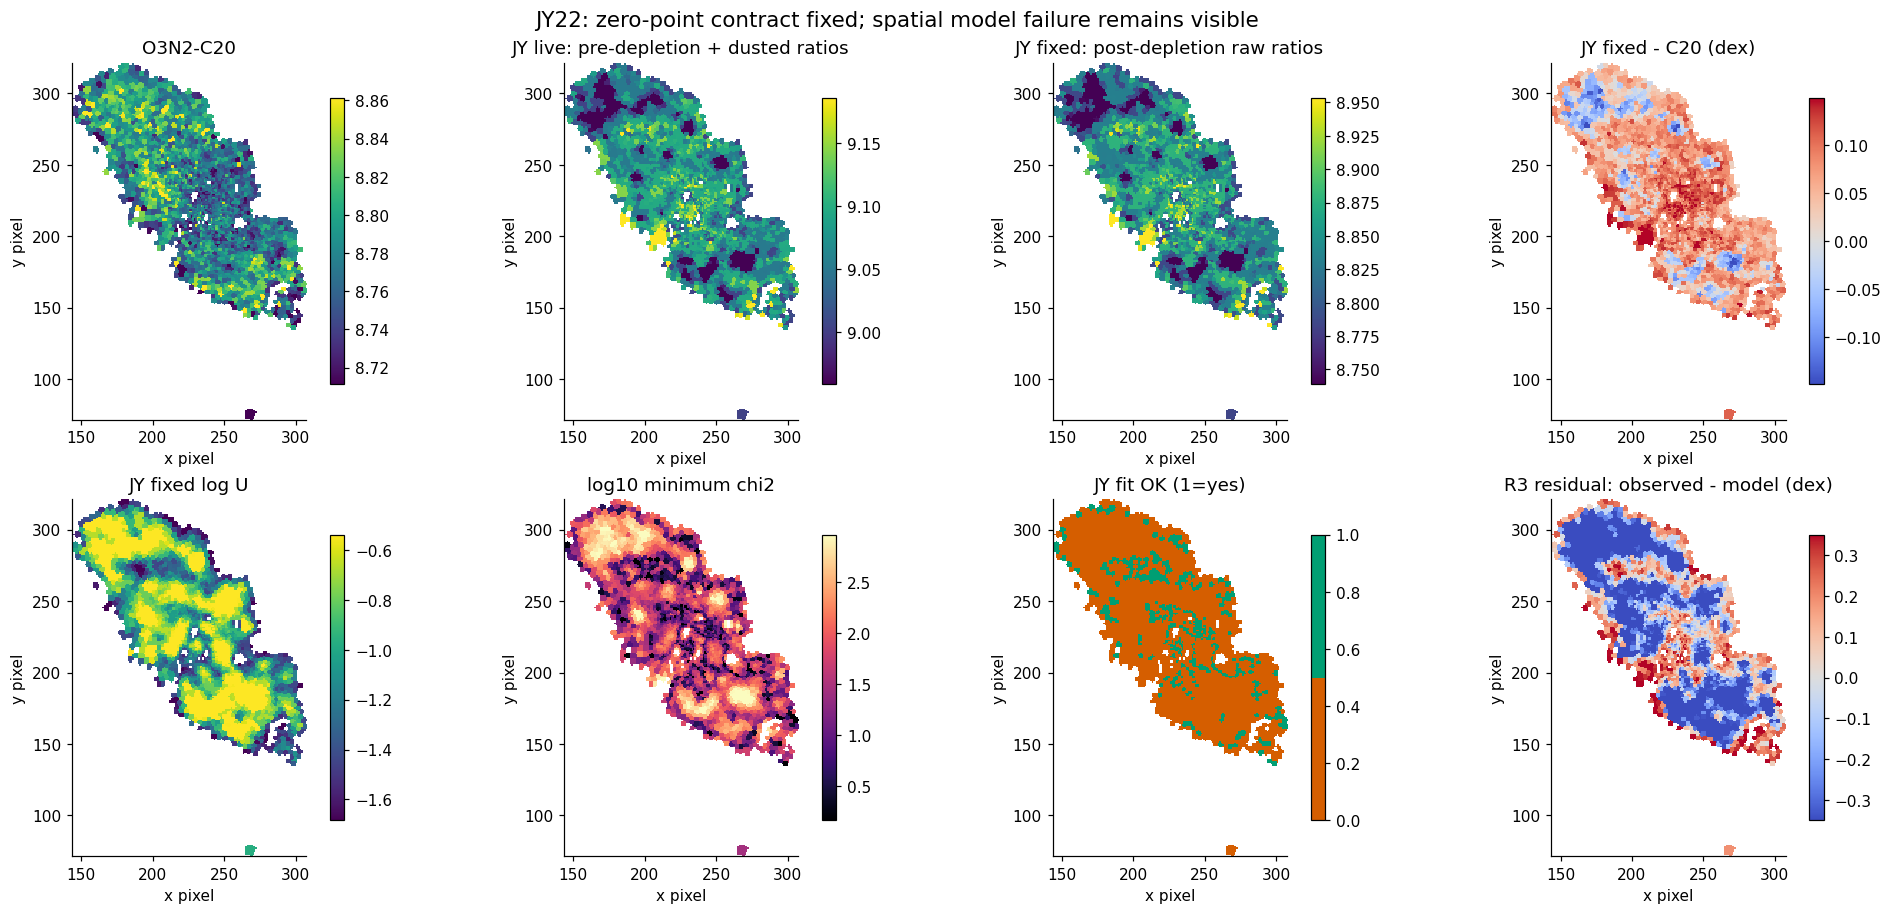

In [8]:
delta_jy_c20_map = fixed_maps["JY post-depletion O/H"] - maps["O_H_O3N2_C20_HII"]
delta_limit = np.nanpercentile(np.abs(delta_jy_c20_map), 98)
log_chi2_map = np.log10(np.where(fixed_maps["JY chi2"] > 0, fixed_maps["JY chi2"], np.nan))

fig, axes = plt.subplots(2, 4, figsize=(18, 8.2), constrained_layout=True)
robust_map(axes[0, 0], maps["O_H_O3N2_C20_HII"], "O3N2-C20")
robust_map(axes[0, 1], maps["O_H_JY22_HII"], "JY live: pre-depletion + dusted ratios")
robust_map(axes[0, 2], fixed_maps["JY post-depletion O/H"], "JY fixed: post-depletion raw ratios")
robust_map(
    axes[0, 3], delta_jy_c20_map, "JY fixed - C20 (dex)", cmap="coolwarm",
    norm=TwoSlopeNorm(vcenter=0.0, vmin=-delta_limit, vmax=delta_limit),
)
robust_map(axes[1, 0], fixed_maps["JY log U"], "JY fixed log U")
robust_map(axes[1, 1], log_chi2_map, "log10 minimum chi2", cmap="magma")
robust_map(
    axes[1, 2], fixed_maps["JY fit ok"], "JY fit OK (1=yes)",
    cmap=ListedColormap(["#D55E00", "#009E73"]), vmin=0, vmax=1,
)
robust_map(
    axes[1, 3], fixed_maps["JY R3 residual"], "R3 residual: observed - model (dex)",
    cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0.0, vmin=-0.35, vmax=0.35),
)
fig.suptitle("JY22: zero-point contract fixed; spatial model failure remains visible", fontsize=14)
plt.show()

Robust p98-p02 span: C20=0.1393 dex; fixed JY22=0.1964 dex
The issue is weak spatial/rank agreement, not simply a numerically narrow JY range.


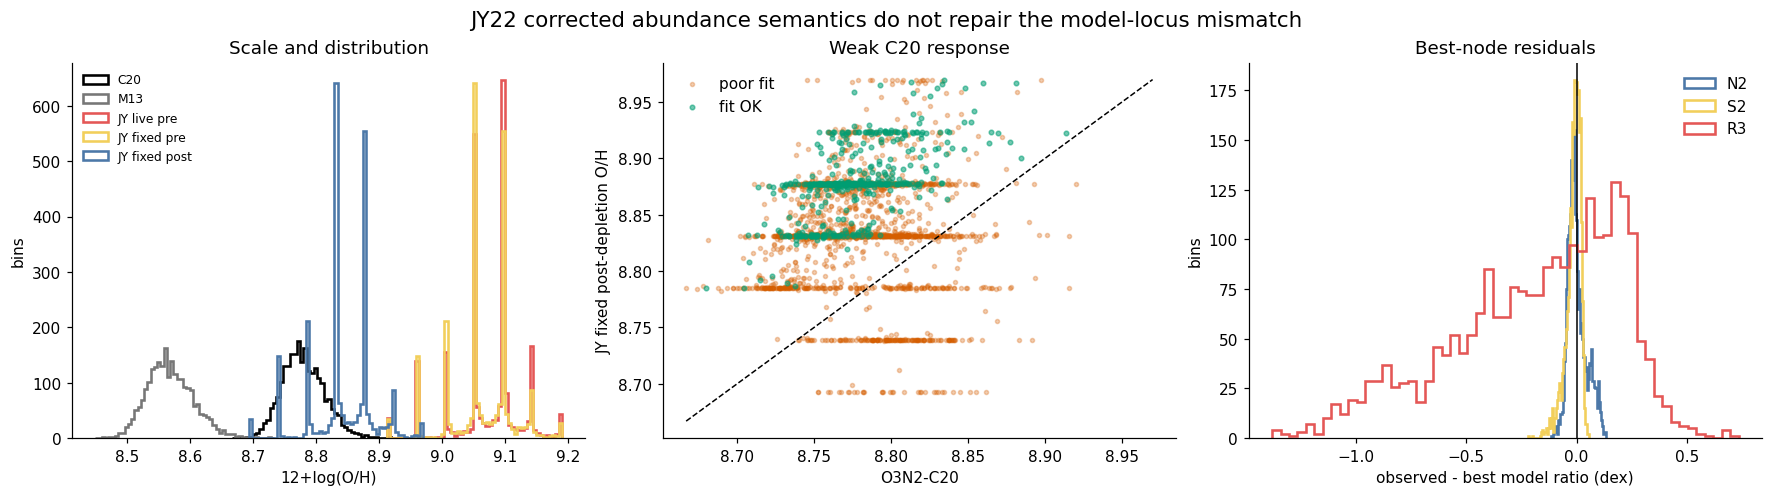

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)

distribution_cases = (
    (fixed["jy_c20"], "C20", "black"),
    (fixed["jy_m13"], "M13", "#777777"),
    (fixed["jy_old_pre"], "JY live pre", "#E45756"),
    (fixed["jy_o_h_pre"], "JY fixed pre", "#F2CF5B"),
    (fixed["jy_o_h"], "JY fixed post", "#4C78A8"),
)
for values, label, color in distribution_cases:
    axes[0].hist(values[np.isfinite(values)], bins=55, histtype="step", lw=1.7, label=label, color=color)
axes[0].set(xlabel="12+log(O/H)", ylabel="bins", title="Scale and distribution")
axes[0].legend(frameon=False, fontsize=8)

fit = jy_common & (fixed["jy_fit_ok"] == 1)
poor = jy_common & (fixed["jy_fit_ok"] == 0)
axes[1].scatter(fixed["jy_c20"][poor], fixed["jy_o_h"][poor], s=7, alpha=0.30, color="#D55E00", label="poor fit")
axes[1].scatter(fixed["jy_c20"][fit], fixed["jy_o_h"][fit], s=9, alpha=0.55, color="#009E73", label="fit OK")
all_limits = [
    min(fixed["jy_c20"][jy_common].min(), fixed["jy_o_h"][jy_common].min()),
    max(fixed["jy_c20"][jy_common].max(), fixed["jy_o_h"][jy_common].max()),
]
axes[1].plot(all_limits, all_limits, "k--", lw=1)
axes[1].set(xlabel="O3N2-C20", ylabel="JY fixed post-depletion O/H", title="Weak C20 response")
axes[1].legend(frameon=False)

for name, color in (("jy_resid_n2", "#4C78A8"), ("jy_resid_s2", "#F2CF5B"), ("jy_resid_r3", "#E45756")):
    label = name.rsplit("_", 1)[-1].upper()
    axes[2].hist(fixed[name][jy_valid], bins=55, histtype="step", lw=1.7, label=label, color=color)
axes[2].axvline(0, color="black", lw=1)
axes[2].set(xlabel="observed - best model ratio (dex)", ylabel="bins", title="Best-node residuals")
axes[2].legend(frameon=False)

fig.suptitle("JY22 corrected abundance semantics do not repair the model-locus mismatch", fontsize=14)
plt.show()

c20_span = np.percentile(fixed["jy_c20"][jy_common], 98) - np.percentile(fixed["jy_c20"][jy_common], 2)
jy_span = np.percentile(fixed["jy_o_h"][jy_common], 98) - np.percentile(fixed["jy_o_h"][jy_common], 2)
print(f"Robust p98-p02 span: C20={c20_span:.4f} dex; fixed JY22={jy_span:.4f} dex")
print("The issue is weak spatial/rank agreement, not simply a numerically narrow JY range.")

### Direct view of the JY22 data-model locus

The released grid is a two-parameter surface in the three observed ratios N2, S2, and R3. If IC3392 lies on that surface within its propagated measurement covariance, all three two-ratio projections should be mutually consistent and the minimum chi-square should be modest.

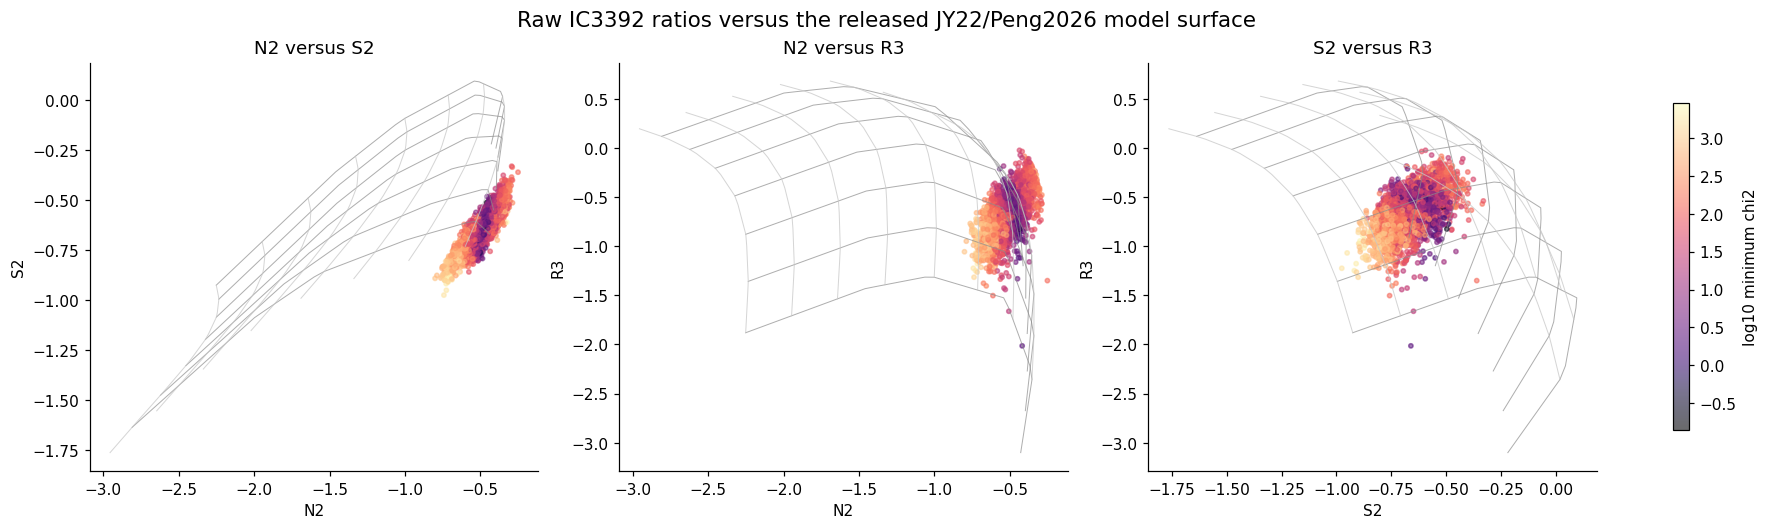

In [10]:
jy_grid = load_jy22_grid(GRID_PATH)
observed_ratios = fixed["jy_log_ratios"]
point_color = np.log10(np.clip(fixed["jy_chi2_min"], 1e-3, None))
pairs = ((0, 1, "N2", "S2"), (0, 2, "N2", "R3"), (1, 2, "S2", "R3"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), constrained_layout=True)
for ax, (x_index, y_index, x_label, y_label) in zip(axes, pairs, strict=True):
    for u_index in range(0, jy_grid.log_u.size, 4):
        ax.plot(
            jy_grid.model_ratios[:, u_index, x_index],
            jy_grid.model_ratios[:, u_index, y_index],
            color="0.55", lw=0.65, alpha=0.70,
        )
    for z_index in range(0, jy_grid.o_h.size, 5):
        ax.plot(
            jy_grid.model_ratios[z_index, :, x_index],
            jy_grid.model_ratios[z_index, :, y_index],
            color="0.78", lw=0.65, alpha=0.75,
        )
    scatter = ax.scatter(
        observed_ratios[:, x_index], observed_ratios[:, y_index],
        c=point_color, s=8, cmap="magma", alpha=0.58, rasterized=True,
    )
    ax.set(xlabel=x_label, ylabel=y_label, title=f"{x_label} versus {y_label}")

fig.colorbar(scatter, ax=axes.tolist(), shrink=0.80, label="log10 minimum chi2")
fig.suptitle("Raw IC3392 ratios versus the released JY22/Peng2026 model surface", fontsize=14)
plt.show()

### JY22 decision

- **Fixed:** raw close-pair ratios and their raw shared-denominator covariance; explicit pre-/post-depletion abundance scales; post-depletion public O/H for gas-phase comparisons.
- **Added:** observed-minus-best-model N2/S2/R3 residuals, their norm, and `JY22_FIT_OK` with poor-fit bit 32. `VALID` continues to mean numerical success so an off-surface bin is never silently discarded.
- **Not fixed by grid density:** the 200-by-200 controlled resampling changed per-bin median O/H by only about 0.0006 dex.
- **Remaining issue is real for this model/data combination:** N2+S2, N2+R3, and S2+R3 yield mutually inconsistent abundances; most bins have minimum chi-square above 9; and R3 remains systematically under-predicted at the N2/S2-dominated best solution.

This does not prove that IC3392 has the C20 metallicity. It proves that the fixed JY22 model surface, likelihood, and assumptions cannot describe most of these IC3392 ratio triplets within their formal measurement errors. Adding an arbitrary model scatter or tuning to C20 would hide that result rather than repair the method.

## 5. Product-level decisions and remaining risks

| Area | Accepted production behavior | Remaining scientific/QC limit |
|---|---|---|
| NebulaBayes O/H, log U, log P/k | Public central maps are posterior means; sampled modes retained as `*_MODE` | Mean removes banding but does not make boundary-constrained parameters reliable |
| NebulaBayes pressure | `NB_LOGPK_RELIABLE` separates finite output from usable pressure | About half of IC3392 reaches the low-density/low-pressure model boundary; a scientifically justified broader grid would require a separate validation |
| NebulaBayes fit diagnostic | Existing `NB_CHI2_RED` retained with corrected provenance text | It is not the posterior objective at the reported means and should not be used as a standard reduced chi-square cut |
| JY22 O/H scale | `O_H_JY22` is post-depletion; `O_H_JY22_PREDEP` preserves the model scale | Calibration agreement does not imply a good line-ratio fit |
| JY22 ratios/covariance | Raw N2/S2/R3 with full raw shared-denominator covariance | IC3392 remains largely off the fixed two-parameter model surface |
| JY22 usability | `JY22_FIT_OK`, residual maps, edge bits, and numerical `VALID` are separate | Only the fit-adequate subset should be considered for method-specific science, and even that subset needs multi-galaxy validation |
| pyqz | No map-level change in this focused pass | Prior QC still treats pyqz as the healthiest new map product; its integrated-aperture behavior remains a separate follow-up |

D16, PG16, and M13 remain useful secondary calibration-sensitivity references. They should not be used to tune the new grid methods, and the next step should be a small, diverse multi-galaxy validation before paper-level use.

In [11]:
fit_ok_count = int(np.count_nonzero(fixed["jy_fit_ok"][jy_valid] == 1))
jy_valid_count = int(np.count_nonzero(jy_valid))
nb_mode_unique = int(np.unique(np.round(nb_mode[nb_keep], 8)).size)
nb_mean_unique = int(np.unique(np.round(nb_mean[nb_keep], 8)).size)

display(
    Markdown(
        f'''
        ## Bottom line

        **NebulaBayes discreteness is fixed at the estimator/output level:** the same {nb_keep.sum():,} finite IC3392 bins occupy {nb_mode_unique} sampled-mode values but {nb_mean_unique} posterior-mean values. The pressure issue is not a sampling artifact and remains explicitly flagged; only {np.mean(nb_logpk_reliable):.1%} of the evaluated pressure estimates pass the frozen parameter-specific reliability definition.

        **JY22 had real script-contract errors, but correcting them does not make the IC3392 distribution trustworthy.** The post-depletion median offset is now {np.median(fixed['jy_o_h'][jy_common] - fixed['jy_c20'][jy_common]):+.3f} dex relative to C20, not the old roughly +0.30 dex. However, its C20 rank correlation is only {spearmanr(fixed['jy_c20'][jy_common], fixed['jy_o_h'][jy_common]).statistic:.2f}, the median minimum chi-square is {np.median(fixed['jy_chi2_min'][jy_valid]):.1f}, and only {fit_ok_count}/{jy_valid_count} ({fit_ok_count / jy_valid_count:.1%}) numerically valid bins meet the nominal chi-square <= {JY22_FORMAL_CHI2_MAX:g} diagnostic.

        Therefore the fixed JY22 O/H maps should be treated as **diagnostic outputs with explicit fit QC**, not as a replacement metallicity field for IC3392. The current production changes expose that limitation rather than concealing it.
        '''
    )
)

assert sha256(FITS_PATH) == live_sha
print("QC complete. The downloaded science FITS remained byte-identical during this notebook.")

QC complete. The downloaded science FITS remained byte-identical during this notebook.



        ## Bottom line

        **NebulaBayes discreteness is fixed at the estimator/output level:** the same 2,404 finite IC3392 bins occupy 32 sampled-mode values but 2404 posterior-mean values. The pressure issue is not a sampling artifact and remains explicitly flagged; only 44.5% of the evaluated pressure estimates pass the frozen parameter-specific reliability definition.

        **JY22 had real script-contract errors, but correcting them does not make the IC3392 distribution trustworthy.** The post-depletion median offset is now +0.075 dex relative to C20, not the old roughly +0.30 dex. However, its C20 rank correlation is only 0.12, the median minimum chi-square is 53.3, and only 440/2404 (18.3%) numerically valid bins meet the nominal chi-square <= 9 diagnostic.

        Therefore the fixed JY22 O/H maps should be treated as **diagnostic outputs with explicit fit QC**, not as a replacement metallicity field for IC3392. The current production changes expose that limitation rather than concealing it.
        